# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [6]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = r'online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


In [7]:
df.to_pickle('online_retail.pkl')
#df = pd.read_pickle('online_retail.pkl')

## 2. Primera inspección

In [8]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [10]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## 3. Calidad de datos

In [11]:
# 1. Análisis de Valores Nulos
print("\n1. VALORES NULOS POR COLUMNA:")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

# Creamos un DataFrame resumen solo con las columnas que tienen nulos
resumen_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos, 
    'Porcentaje (%)': porcentaje_nulos.round(2)
})
print(resumen_nulos[resumen_nulos['Cantidad de Nulos'] > 0])


1. VALORES NULOS POR COLUMNA:
             Cantidad de Nulos  Porcentaje (%)
Description               4382            0.41
Customer ID             243007           22.77


In [12]:
# 2. Análisis de Duplicados
print("\n2. VALORES DUPLICADOS:")
duplicados = df.duplicated().sum()
porcentaje_duplicados = (duplicados / len(df)) * 100

print(f"Filas exactamente idénticas: {duplicados}")
print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")


2. VALORES DUPLICADOS:
Filas exactamente idénticas: 34335
Porcentaje de duplicados: 3.22%


In [13]:
# 3. Tratamiento de Duplicados
# Lo más seguro es eliminarlos.
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"\nAcción: Se han eliminado {duplicados} filas duplicadas.")
    print(f"Nuestro dataset se queda con {len(df)} filas para el modelo.")


Acción: Se han eliminado 34335 filas duplicadas.
Nuestro dataset se queda con 1033036 filas para el modelo.


In [14]:
# ---------------------------------------------------------
# LIMPIEZA DE DATOS
# ---------------------------------------------------------

print("LIMPIANDO DATASET...")

# Eliminamos las filas que corresponden a devoluciones (Invoice que empiezan con 'C')
df_clean = df[~df['Invoice'].astype(str).str.startswith('C')]

# Nos quedamos solo con las filas que tienen Customer ID (clientes identificados)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Calculamos la facturación por fila (Revenue = Quantity * Price)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"Original rows: {len(df)}")
print(f"Clean rows ready for analysis: {len(df_clean)}")

LIMPIANDO DATASET...
Original rows: 1033036
Clean rows ready for analysis: 1007913


## 4. Estadísticas descriptivas
df.describe()

In [15]:
print("--- ESTADÍSTICA DESCRIPTIVA ---")

# Generamos estadísticas descriptiva para las variables numéricas
print("\n1. RESUMEN DE VARIABLES NUMÉRICAS:")
# Vamos a crear la variable Revenue para tener una métrica de ventas
numerical_summary = df_clean[['Quantity', 'Price', 'Revenue']].describe().round(2)
display(numerical_summary)

# Generamos resumen para las columnas categóricas para observar valores únicos y ocurrencias más comunes
print("\n2. RESUMEN DE VARIABLES CATEGÓRICAS:")
categorical_summary = df_clean[['Invoice', 'StockCode', 'Description', 'Country']].astype(str).describe()
display(categorical_summary)

# Calculamos métricas de forma de distribución para las variables numéricas
print("\n3. MÉTRICAS DE FORMA DE DISTRIBUCIÓN:")

# Medidas de asimetría (skewness) para entender la simetría de la distribución
print("Asimetría (Skewness):")
display(df_clean[['Quantity', 'Price', 'Revenue']].skew().round(2))

# Medidas de curtosis (kurtosis) para entender las colas de la distribución
print("\nCurtosis (Kurtosis):")
display(df_clean[['Quantity', 'Price', 'Revenue']].kurtosis().round(2))

--- ESTADÍSTICA DESCRIPTIVA ---

1. RESUMEN DE VARIABLES NUMÉRICAS:


,Quantity,Price,Revenue
count,1007913.00,1007913.00,1007913.00
mean,11.12,4.07,20.32
std,128.47,50.43,205.72
min,1.00,0.00,0.00
25%,1.00,1.25,4.13
50%,4.00,2.10,10.08
75%,12.00,4.13,17.70
max,80995.00,25111.09,168469.60



2. RESUMEN DE VARIABLES CATEGÓRICAS:


,Invoice,StockCode,Description,Country
count,1007913,1007913,1007913,1007913
unique,40077,4917,5399,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,5511,5601,926038



3. MÉTRICAS DE FORMA DE DISTRIBUCIÓN:
Asimetría (Skewness):


Quantity    453.99
Price       234.73
Revenue     608.61
dtype: float64


Curtosis (Kurtosis):


Quantity    268348.06
Price        82653.85
Revenue     467313.52
dtype: float64

## 5. Visualizaciones

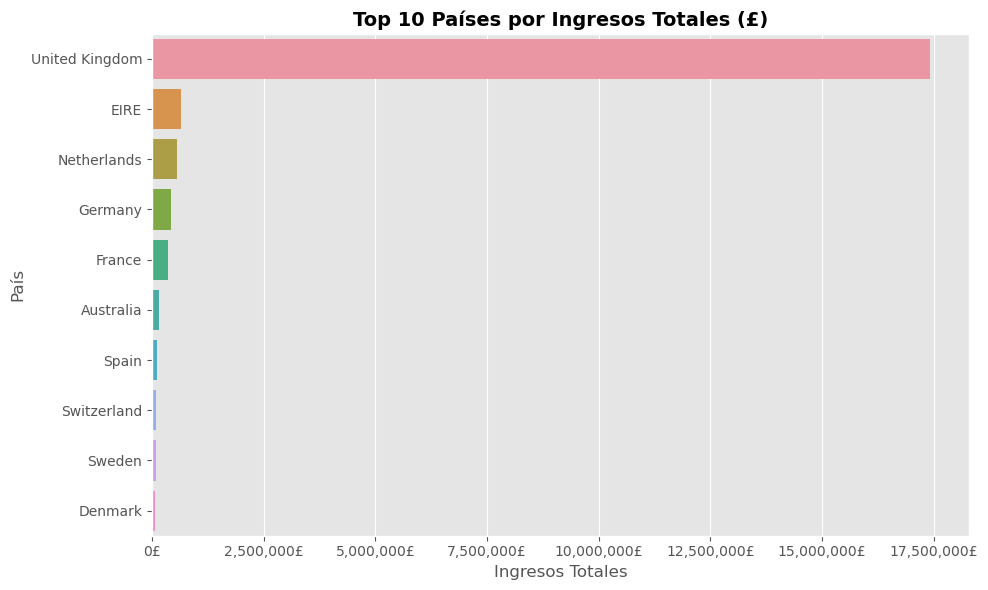

In [16]:
# ---------------------------------------------------------
# GRÁFICA 1: TOP 10 PAÍSES POR VOLUMEN DE INGRESOS
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Group by country, sum revenue, sort descending and get top 10
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

# Create barplot (it will inherit the 'husl' palette automatically)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Países por Ingresos Totales (£)', fontsize=14, fontweight='bold')
plt.xlabel('Ingresos Totales', fontsize=12)
plt.ylabel('País', fontsize=12)

# Add currency format to X axis for better readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}£".format(int(x))))
plt.tight_layout()
plt.show()

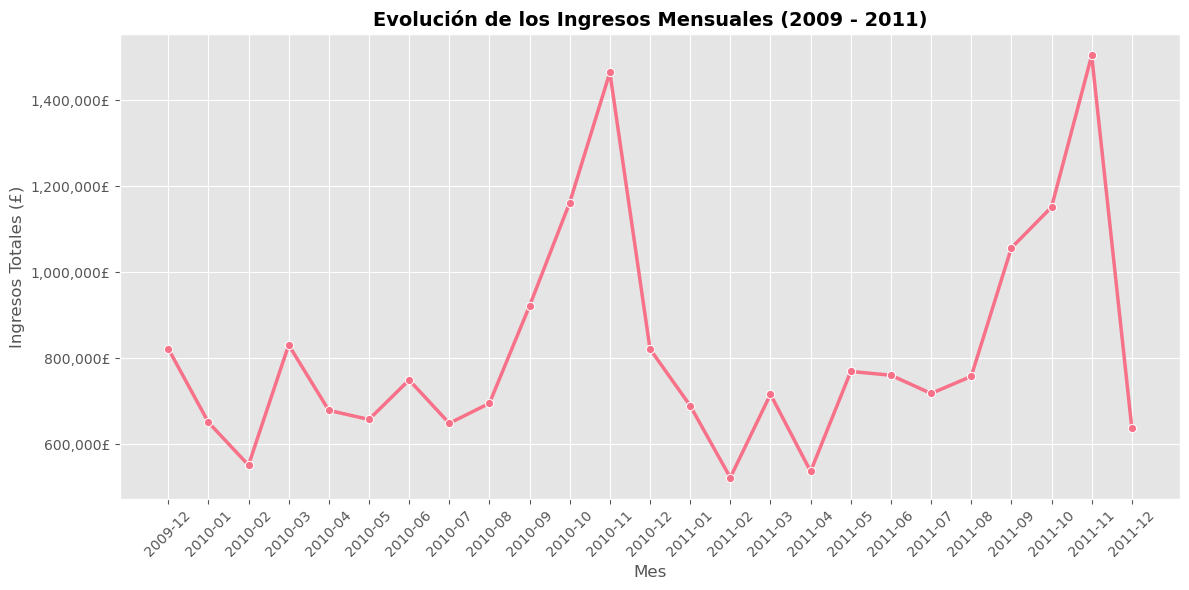

In [17]:
# ---------------------------------------------------------
# GRÁFICO 2: INGRESOS MENSUALES (EVOLUCIÓN TEMPORAL)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Creamos una nueva columna 'YearMonth' para agrupar por mes y año
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum()

# Convertimos el índice a string para que se muestre como 'YYYY-MM' en el gráfico
monthly_revenue.index = monthly_revenue.index.astype(str)

# Línea de tiempo para la serie temporal (heredará el estilo 'ggplot')
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', linewidth=2.5)
plt.title('Evolución de los Ingresos Mensuales (2009 - 2011)', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos Totales (£)', fontsize=12)
plt.xticks(rotation=45) 
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:,}£".format(int(y))))
plt.tight_layout()
plt.show()

# Eliminamos la columna temporal 'YearMonth' que solo se usó para el gráfico
df_clean = df_clean.drop('YearMonth', axis=1)

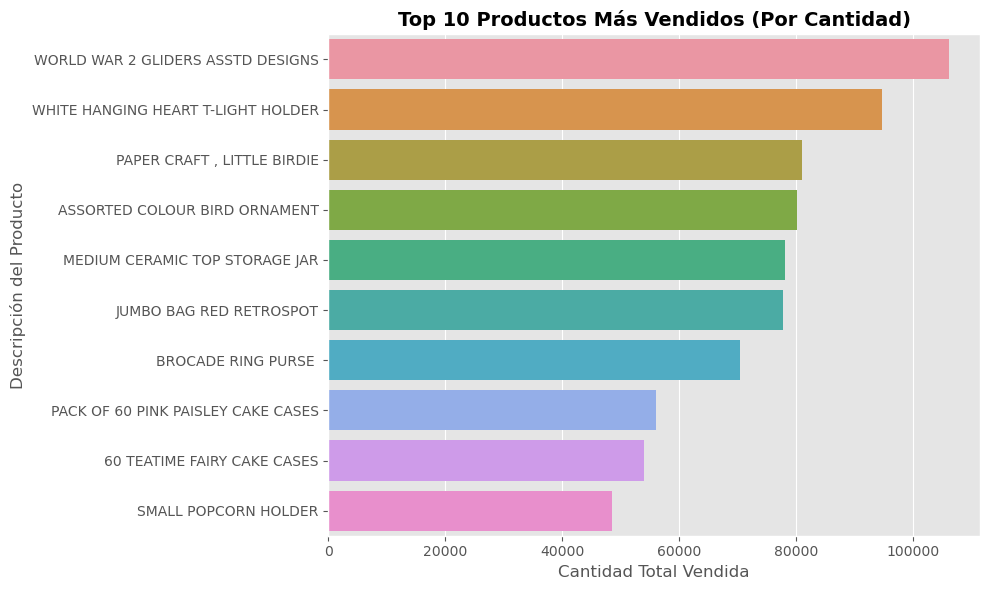

In [18]:
# ---------------------------------------------------------
# GRÁFICO 3: TOP 10 PRODUCTOS MÁS VENDIDOS (POR CANTIDAD)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Agrupamos por descripción del producto, sumamos la cantidad, ordenamos y obtenemos el top 10
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Creamos un barplot para los productos más vendidos (heredará la paleta 'husl')
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Productos Más Vendidos (Por Cantidad)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad Total Vendida', fontsize=12)
plt.ylabel('Descripción del Producto', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Agrupación por cliente (Customer ID)

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [19]:
# ---------------------------------------------------------
# 6. AGREGACIÓN A NIVEL CLIENTE PARA PERFILADO DE COMPORTAMIENTO
# ---------------------------------------------------------

# Agrupamos el dataset por Customer ID para calcular métricas de comportamiento
customer_aggregation = df_clean.groupby('Customer ID').agg({
    'Revenue': 'sum',          # Totales de facturación por cliente (suma de tickets)
    'Invoice': 'nunique'       # Número de compras únicas (facturas distintas)
})

# Renombramos las columnas para mayor claridad en el contexto de negocio
customer_aggregation.columns = ['Total_Revenue', 'Number_of_Purchases']

# Calculamos el ticket promedio por compra (Total Revenue / Distinct Invoices)
customer_aggregation['Average_Ticket'] = customer_aggregation['Total_Revenue'] / customer_aggregation['Number_of_Purchases']

# Redondeamos los resultados numéricos a dos decimales para mayor limpieza
customer_aggregation = customer_aggregation.round(2)

# Mostramos las primeras filas del perfilado de clientes
print("Agregación a nivel cliente completada exitosamente:")
display(customer_aggregation.head())

Agregación a nivel cliente completada exitosamente:


,Total_Revenue,Number_of_Purchases,Average_Ticket
Customer ID,,,
12346.0,77556.46,12,6463.04
12347.0,4921.53,8,615.19
12348.0,2019.40,5,403.88
12349.0,4428.69,4,1107.17
12350.0,334.40,1,334.40


## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

In [20]:
# ---------------------------------------------------------
# 7. MODELO: PROBABILIDAD DE RECOMPRA (REGRESIÓN LOGÍSTICA)
# ---------------------------------------------------------

print("CONSTRUYENDO EL MODELO SUPERVISADO...")

# Paso 1: Definimos la fecha de corte (6 meses antes de la fecha máxima para evitar data leakage)
max_date = df_clean['InvoiceDate'].max()
cutoff_date = max_date - pd.DateOffset(months=6)
print(f"Fecha de corte establecida en: {cutoff_date.date()}")

CONSTRUYENDO EL MODELO SUPERVISADO...
Fecha de corte establecida en: 2011-06-09


In [21]:
# Paso 2: Segmentamos los datos en ventana de características (pasado) y ventana de predicción (futuro)
df_hist = df_clean[df_clean['InvoiceDate'] < cutoff_date]
df_target = df_clean[df_clean['InvoiceDate'] >= cutoff_date]

In [22]:
# Paso 3: Identificamos los clientes únicos que realmente repitieron compra en la ventana futura
repurchased_customers = df_target['Customer ID'].unique()

In [23]:
# Paso 4: Agregamos el comportamiento transaccional pasado para construir características por cliente
# Incluimos una característica binaria para el País (1 si Reino Unido, 0 en caso contrario) debido a su alto volumen
rfm_model = df_hist.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (cutoff_date - x.max()).days,  # Reciente
    'Invoice': 'nunique',                                   # Frecuencia
    'Revenue': 'sum',                                       # Gasto total
    'Country': lambda x: 1 if x.iloc[0] == 'United Kingdom' else 0 # Si es de UK
})

# Renombramos las columnas para mayor claridad analítica
rfm_model.columns = ['Recency', 'Frequency', 'Total_Spend', 'Is_UK']

# Calculamos la característica de ticket promedio por compra (Total Spend / Frequency)
rfm_model['Avg_Ticket'] = rfm_model['Total_Spend'] / rfm_model['Frequency']

In [25]:
# Step 5: Creamos la variable objetivo binaria (1 = repurchased, 0 = no repurchased)
rfm_model['Repurchased'] = rfm_model.index.isin(repurchased_customers).astype(int)

In [26]:
# Paso 6: Preparamos los datos para el modelo (X = características, y = objetivo)
X = rfm_model[['Recency', 'Frequency', 'Total_Spend', 'Avg_Ticket', 'Is_UK']]
y = rfm_model['Repurchased']

In [27]:
# Paso 7: Dividimos los datos en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# Paso 8: Escalamos las características numéricas para mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# Paso 9: Entrenamos un modelo de regresión logística para predecir la probabilidad de recompra
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
# Paso 10: Predecimos probabilidades para el conjunto de prueba
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [31]:
# Paso 11: Calculamos y mostramos la métrica AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Métrica AUC del Modelo de Regresión Logística: {auc_score:.4f}")

Métrica AUC del Modelo de Regresión Logística: 0.7899


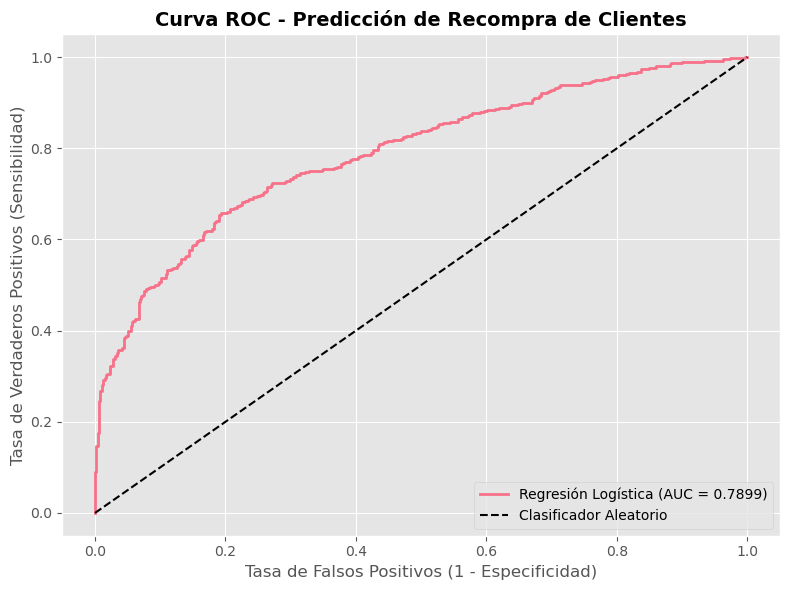

In [33]:
# Paso 12: Graficamos la curva ROC para visualizar el rendimiento del modelo
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.title('Curva ROC - Predicción de Recompra de Clientes', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [34]:


# ---------------------------------------------------------
# PREDICCIÓN DE RECOMPRA PARA UN CLIENTE ESPECÍFICO
# ---------------------------------------------------------

print("PREDICCIÓN DE RECOMPRA PARA UN CLIENTE ESPECÍFICO...")
customer_data = pd.DataFrame({
    'Recency': [30],
    'Frequency': [4],
    'Total_Spend': [500.0],
    'Avg_Ticket': [500.0 / 4],  # Gasto total dividido por número de compras
    'Is_UK': [1]
})

print("\nPerfil del Cliente a evaluar:")
display(customer_data)

# Paso 2: Escalamos las caracterísitcas del nuevo cliente usando el Scaler ya ajustado.
# Usamos transorm(), NUNCA fit_transform() en datos nuevos
customer_scaled = scaler.transform(customer_data)

# Paso 3: Predicimos la probabilidad de recompra (devuelve un array, extraemos la probabilidad de la clase 1)
probability = log_reg.predict_proba(customer_scaled)[0, 1]

# Paso 4: Predicimos la clase binaria final (1 = Comprará de nuevo, 0 = No comprará de nuevo)
prediction_class = log_reg.predict(customer_scaled)[0]

# Paso 5: Mostramos los resultados en un formato amigable para el negocio
print("\n--- RESULTADOS DE LA PREDICCIÓN ---")
print(f"Probabilidad de recompra: {probability * 100:.2f}%")

if prediction_class == 1:
    print(" Diagnóstico: Cliente LEAL (Alta probabilidad).")
    print("Acción Comercial: Incluir en campaña de Fidelización (Ej. Acceso anticipado a nuevos productos).")
else:
    print("Diagnóstico: Cliente EN RIESGO DE ABANDONO (Baja probabilidad).")
    print("Acción Comercial: Incluir en campaña de Retención (Ej. Enviar cupón de descuento agresivo).")

PREDICCIÓN DE RECOMPRA PARA UN CLIENTE ESPECÍFICO...

Perfil del Cliente a evaluar:


,Recency,Frequency,Total_Spend,Avg_Ticket,Is_UK
0,30,4,500.0,125.0,1



--- RESULTADOS DE LA PREDICCIÓN ---
Probabilidad de recompra: 70.44%
 Diagnóstico: Cliente LEAL (Alta probabilidad).
Acción Comercial: Incluir en campaña de Fidelización (Ej. Acceso anticipado a nuevos productos).


### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


In [36]:
# ---------------------------------------------------------
# 9.HIPERPARÁMETROS: OPTIMIZACIÓN CON RANDOM SEARCH
# ---------------------------------------------------------

print("OPTIMIZANDO EL MODELO CON RANDOM SEARCH...")

# Definimos el modelo base para la búsqueda de hiperparámetros
log_reg_base = LogisticRegression(random_state=42, max_iter=2000)

# Definimos el espacio de hiperparámetros a explorar    
# Inversamente proporcional a la fuerza de regularización (valores más pequeños = regularización más fuerte)
# Penalización L2 (Ridge) o sin penalización (None)
param_distributions = {
    'C': loguniform(1e-3, 1e3),
    'penalty': ['l2', 'none'],
    'class_weight': [None, 'balanced']
}

# Inicializamos RandomizedSearchCV
# n_iter = 20 significa que probará aleatoriamente 20 combinaciones diferentes del espacio definido arriba
random_search = RandomizedSearchCV(
    estimator=log_reg_base,
    param_distributions=param_distributions,
    n_iter=20, 
    scoring='roc_auc', # Optimizamos para AUC, que es una métrica robusta para clasificación binaria
    cv=5,              # cross-validation de 5 folds para asegurar robustez
    random_state=42,
    n_jobs=-1          # Usamos todos los núcleos del procesador para acelerar la búsqueda
)

# Ejecutamos la búsqueda sobre los datos de entrenamiento escalados
print("Buscando la mejor combinación de hiperparámetros (esto puede tardar unos segundos)...")
random_search.fit(X_train_scaled, y_train)

# Extraemos el mejor modelo encontrado por RandomizedSearchCV
log_reg = random_search.best_estimator_

print("\n ¡Búsqueda completada!")
print(f"Mejores hiperparámetros encontrados: {random_search.best_params_}")

OPTIMIZANDO EL MODELO CON RANDOM SEARCH...
Buscando la mejor combinación de hiperparámetros (esto puede tardar unos segundos)...

 ¡Búsqueda completada!
Mejores hiperparámetros encontrados: {'C': 4.418441521199722, 'class_weight': None, 'penalty': 'l2'}


## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. COn Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()



ANALIZANDO LA EXPLICABILIDAD DEL MODELO...


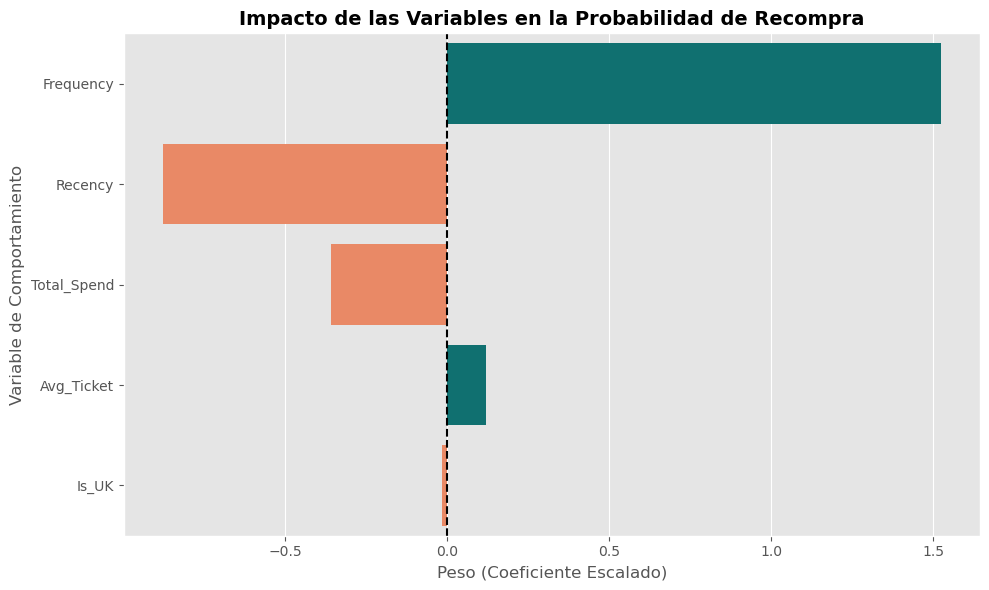

,Variable,Coeficiente
1,Frequency,1.5236
0,Recency,-0.8772
2,Total_Spend,-0.3581
3,Avg_Ticket,0.1200
4,Is_UK,-0.0161


In [37]:
# ---------------------------------------------------------
# 8. EXPLICABILIDAD DEL MODELO: IMPACTO DE LAS VARIABLES EN LA PROBABILIDAD DE RECOMPRA
# ---------------------------------------------------------

print("ANALIZANDO LA EXPLICABILIDAD DEL MODELO...")

# 1. Extraemos los coeficientes del modelo de Regresión Logística
# (Si usaste la búsqueda aleatoria, log_reg ya es tu mejor modelo)
coeficientes = log_reg.coef_[0]
nombres_variables = X.columns

# 2. Creamos un DataFrame para ordenar las variables por su impacto real (valor absoluto)
importancia_df = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': abs(coeficientes)
}).sort_values(by='Importancia_Absoluta', ascending=False)

# 3. Visualización orientada a negocio
plt.figure(figsize=(10, 6))

# Lógica de colores: Teal (positivo/recompra) vs Coral (negativo/abandono)
colores = ['teal' if c > 0 else 'coral' for c in importancia_df['Coeficiente']]

sns.barplot(x='Coeficiente', y='Variable', data=importancia_df, palette=colores)

# Ajustes de diseño
plt.title('Impacto de las Variables en la Probabilidad de Recompra', fontsize=14, fontweight='bold')
plt.xlabel('Peso (Coeficiente Escalado)', fontsize=12)
plt.ylabel('Variable de Comportamiento', fontsize=12)

# Añadimos una línea vertical central en el 0 para separar impactos positivos de negativos
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

# 4. Mostrar la tabla exacta para documentar en el Notebook
display(importancia_df[['Variable', 'Coeficiente']].round(4))